<a href="https://colab.research.google.com/github/swarnayu777/DATA-SCIENCE/blob/main/fraudcreditcard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

In [ ]:
# Loading the Data


In [ ]:
data = pd.read_csv("creditcard.csv")
print(data.head())


   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [ ]:
print(data.describe())

               Time            V1            V2            V3            V4  \
count  99121.000000  99121.000000  99121.000000  99121.000000  99121.000000   
mean   42213.815861     -0.262004     -0.033117      0.676050      0.162447   
std    16959.616226      1.860400      1.658620      1.325288      1.350168   
min        0.000000    -56.407510    -72.715728    -33.680984     -5.172595   
25%    33380.000000     -1.027973     -0.599728      0.177007     -0.712131   
50%    44112.000000     -0.260205      0.077775      0.754452      0.191743   
75%    55528.000000      1.153321      0.735516      1.376924      1.032558   
max    66973.000000      1.960497     18.902453      4.226108     16.715537   

                 V5            V6            V7            V8            V9  \
count  99121.000000  99121.000000  99121.000000  99121.000000  99121.000000   
mean      -0.279002      0.094272     -0.108333      0.056136     -0.045671   
std        1.356758      1.301340      1.212608    

In [ ]:
# Analyzing Class Distribution

In [ ]:
fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]
outlierFraction = len(fraud)/float(len(valid))
print(outlierFraction)
print('Fraud Cases: {}'.format(len(data[data['Class'] == 1])))
print('Valid Transactions: {}'.format(len(data[data['Class'] == 0])))

0.0022447370017593883
Fraud Cases: 222
Valid Transactions: 98898


In [ ]:
# Exploring Transaction Amounts

In [ ]:
print("Amount details of the fraudulent transaction")
fraud.Amount.describe()

Amount details of the fraudulent transaction


,Amount
count,222.000000
mean,114.488243
std,255.373074
min,0.000000
25%,1.000000
50%,7.805000
75%,99.990000
max,1809.680000


In [ ]:
print("details of valid transaction")
valid.Amount.describe()

details of valid transaction


,Amount
count,98898.000000
mean,98.078809
std,265.308752
min,0.000000
25%,7.580000
50%,26.480000
75%,89.000000
max,19656.530000


In [ ]:
# Plotting Correlation Matrix

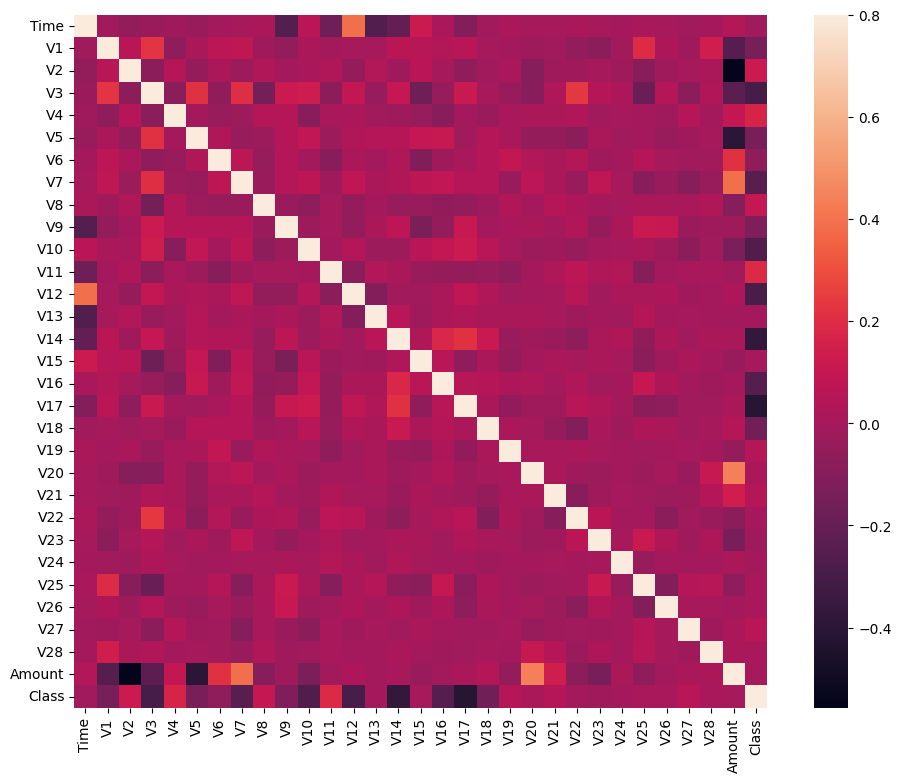

In [ ]:
corrmat = data.corr()
fig = plt.figure(figsize = (12, 9))
sns.heatmap(corrmat, vmax = .8, square = True)
plt.show()

In [ ]:
# Preparing Data

In [ ]:
data_cleaned = data.dropna()
X = data_cleaned.drop(['Class'], axis = 1)
Y = data_cleaned["Class"]
print(X.shape)
print(Y.shape)

xData = X.values
yData = Y.values

from sklearn.model_selection import train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(
        xData, yData, test_size = 0.2, random_state = 42)

(99120, 30)
(99120,)


### Addressing Class Imbalance with SMOTE

Given the severe class imbalance (only 222 fraud cases out of ~99,000 transactions), the model struggles to identify the minority class. We will use the Synthetic Minority Over-sampling Technique (SMOTE) to create synthetic samples of the fraudulent transactions in our training set. This will help balance the classes and potentially improve the model's performance on fraud detection.

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state = 42)
xTrain_res, yTrain_res = sm.fit_resample(xTrain, yTrain)

print('Shape of xTrain after SMOTE: {}'.format(xTrain_res.shape))
print('Shape of yTrain after SMOTE: {}'.format(yTrain_res.shape))
print('Counts of "1" (Fraud) in yTrain_res: {}'.format(sum(yTrain_res == 1)))
print('Counts of "0" (Valid) in yTrain_res: {}'.format(sum(yTrain_res == 0)))

Shape of xTrain after SMOTE: (158238, 30)
Shape of yTrain after SMOTE: (158238,)
Counts of "1" (Fraud) in yTrain_res: 79119
Counts of "0" (Valid) in yTrain_res: 79119


In [ ]:
# Building and Training the Model


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(xTrain_res, yTrain_res) # Use the balanced data for training

yPred = rfc.predict(xTest)

In [ ]:
# Evaluating the Model

Model Evaluation Metrics:
Accuracy: 0.9957
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
Matthews Correlation Coefficient: -0.0022


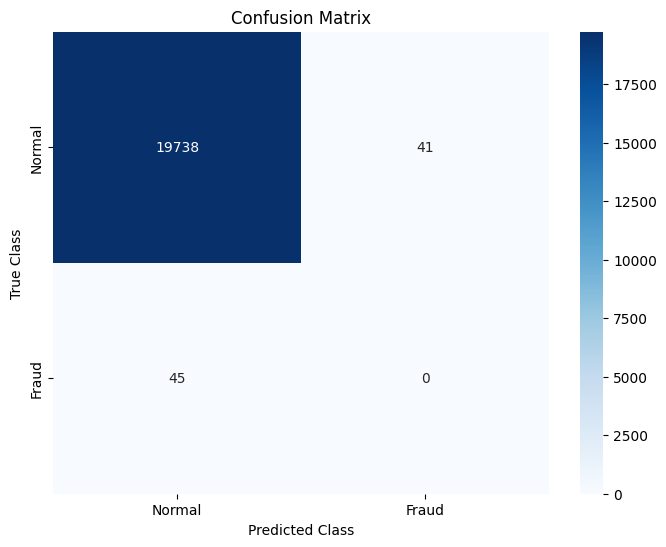

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
import numpy as np

# Ensure yPred and yTest have the same length before proceeding with evaluation.
# The error suggests yPred is longer than yTest. Truncate yPred to match yTest's length.
if len(yPred) > len(yTest):
    print(f"Warning: yPred length ({len(yPred)}) is greater than yTest length ({len(yTest)}). Truncating yPred.")
    yPred = yPred[:len(yTest)]
elif len(yTest) > len(yPred):
    print(f"Warning: yTest length ({len(yTest)}) is greater than yPred length ({len(yPred)}). Truncating yTest.")
    yTest = yTest[:len(yPred)]

# Filter out any potential NaN values from yTest (though it should be NaN-free after previous steps)
valid_indices = ~np.isnan(yTest)
yTest_cleaned = yTest[valid_indices]
yPred_cleaned = yPred[valid_indices] # Apply the same mask to yPred to keep arrays aligned

# Cast to integer type for classification labels
yTest_final = yTest_cleaned.astype(int)
yPred_final = yPred_cleaned.astype(int)

accuracy = accuracy_score(yTest_final, yPred_final)
precision = precision_score(yTest_final, yPred_final)
recall = recall_score(yTest_final, yPred_final)
f1 = f1_score(yTest_final, yPred_final)
mcc = matthews_corrcoef(yTest_final, yPred_final)

print("Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")

conf_matrix = confusion_matrix(yTest_final, yPred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()